### **Overfitting and Underfitting**

Machine learning models should learn useful patterns from training data. When a model learns too little or too much, we get underfitting or overfitting.

Underfitting means that the model is too simple and does not cover all real patterns in the data.
Overfitting means that the model learns not just the underlying pattern, but also noise or random quirks in the training data. model memorizes training data


A good model finds the right spot, it is complex enough to capture real patterns, but not so complex that it “memorizes” noise

**What is Underfitting?**

Underfitting happens when the model fails to learn important patterns. It performs poorly on both training and testing data. Underfitting happens due to:

Model is too simple

Very high regularization

Features are weak or missing

Not enough training

High bias

**Bias:** It is like assuming all birds can only be small and fly, so the model fails to recognize big birds like ostriches or penguins that can't fly and get biased with predictions.

**Bias–Variance Inside Underfitting**

Underfitting mainly occurs due to high bias:

1. High bias means model makes strong assumptions

2. Ignores patterns

3. Learns an overly simple representation

4. Variance is low because the model gives similar outputs even if the data changes

Underfitting = High Bias + Low Variance

**What is Overfitting?**

Overfitting happens when the model learns too much from the training data, including noise and outliers. It performs very well on training data but poorly on test data. Overfitting happens due to:

1. Model too complex
2. Too many features
3. Very little data
4. No regularization
5. High variance

**Variance:** Error that happens when a machine learning model learns too much from the data, including random noise. 

**Bias–Variance Inside Overfitting**

Overfitting is mainly caused by high variance:

1. High variance means model reacts too strongly to training data
2. Learns noise as patterns
3. Low bias because the model is extremely flexible

Overfitting = Low Bias + High Variance

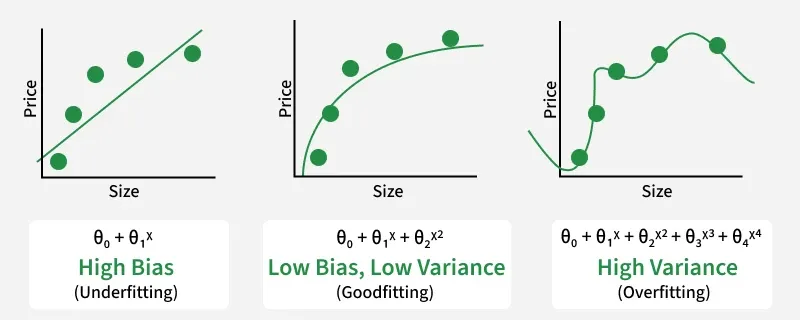

**Underfitting :** Straight line trying to fit a curved dataset but cannot capture the data's patterns, leading to poor performance on both training and test sets.

**Overfitting:** A squiggly curve passing through all training points, failing to generalize performing well on training data but poorly on test data.

**Appropriate Fitting:** Curve that follows the data trend without overcomplicating to capture the true patterns in the data.

**Bias-Variance Tradeoff**

The relationship between bias and variance is often referred to as the bias-variance tradeoff, which highlights the need for balance:

Increasing model complexity reduces bias but increases variance (risk of overfitting).
Simplifying the model reduces variance but increases bias (risk of underfitting).
The goal is to find an optimal balance where both bias and variance are minimized, resulting in good generalization performance.

Imagine predicting house prices based on size. You plot the data and try to draw a curve that represents the trend. How well this curve fits depends on the complexity of the model.



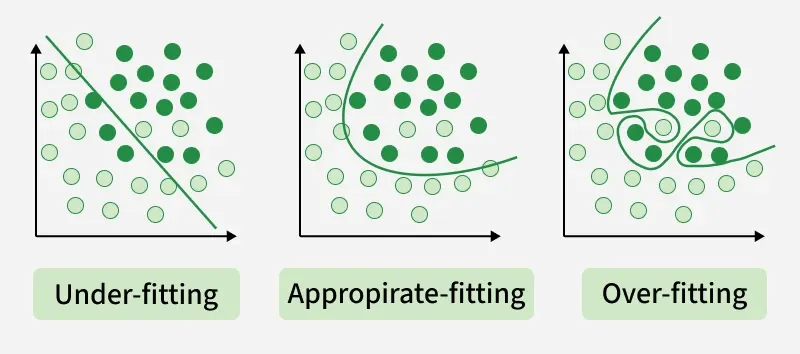

**Underfitting (High Bias):** A model that is too simple (like a straight line for curved data) misses key patterns and performs poorly on both training and testing data.

**Overfitting (High Variance):** A model that is too complex (like a high-degree polynomial) learns noise, fits training data too closely, and performs poorly on new data.

**Ideal Fit (Balanced):** A moderately complex model captures the main trend without following noise, giving good performance on both training and testing data.

**How to Address Overfitting and Underfitting?**

**Techniques to Reduce Underfitting**

1. Use a more complex model
2. Add new features and perform feature engineering
3. Reduce regularization
4. Train for more epochs
5. Scale features properly

**Techniques to Reduce Overfitting**

1. Collect more training data
2. Reduce model complexity
3. Use regularization (L1/L2)
4. Apply dropout (for neural networks)
5. Use early stopping
6. Clean noisy data

### **Regularization Techniques**

Regularization is a technique used in machine learning to prevent overfitting, which otherwise causes models to perform poorly on unseen data. By adding a penalty for complexity, regularization encourages simpler and more generalizable models.

Prevents overfitting: Adds constraints to the model to reduce the risk of memorizing noise in the training data.
Improves generalization: Encourages simpler models that perform better on new, unseen data.

**Types of Regularization**

**1. Lasso Regression**

A regression model which uses the L1 Regularization technique is called LASSO (Least Absolute Shrinkage and Selection Operator) regression. It adds the absolute value of magnitude of the coefficient as a penalty term to the loss function(L). This penalty can shrink some coefficients to zero which helps in selecting only the important features and ignoring the less important ones.

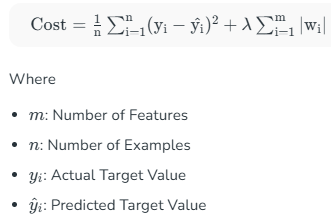

In [2]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

X, y = make_regression(n_samples=100, n_features=5, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred = lasso.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

print("Coefficients:", lasso.coef_)

Mean Squared Error: 0.06362439921332456
Coefficients: [60.50305581 98.52475354 64.3929265  56.96061238 35.52928502]


The output shows the model's prediction error and the importance of features with some coefficients reduced to zero due to L1 regularization.

**2. Ridge Regression**

A regression model that uses the L2 regularization technique is called Ridge regression. It adds the squared magnitude of the coefficient as a penalty term to the loss function(L). It handles multicollinearity by shrinking the coefficients of correlated features instead of eliminating them.

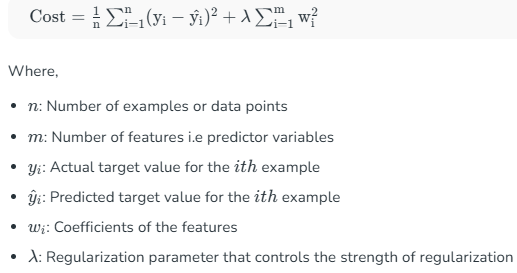

In [3]:
from sklearn.linear_model import Ridge
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X, y = make_regression(n_samples=100, n_features=5, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
print("Coefficients:", ridge.coef_)

Mean Squared Error: 4.114050771972589
Coefficients: [59.87954432 97.15091098 63.24364738 56.31999433 35.34591136]


The output shows the MSE showing model performance. Lower MSE means better accuracy. The coefficients reflect the regularized feature weights.

**3. Elastic Net Regression**

Elastic Net Regression is a combination of both L1 as well as L2 regularization. That shows that we add the absolute norm of the weights as well as the squared measure of the weights. With the help of an extra hyperparameter that controls the ratio of the L1 and L2 regularization.

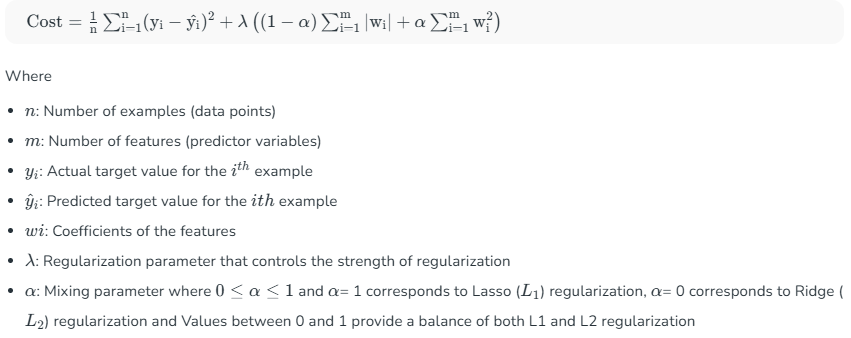

In [4]:
from sklearn.linear_model import ElasticNet
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X, y = make_regression(n_samples=100, n_features=10, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = ElasticNet(alpha=1.0, l1_ratio=0.5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Coefficients:", model.coef_)

Mean Squared Error: 7785.886176938014
Coefficients: [16.84528938 31.77080959  4.05901996 40.18486737 57.25856154 45.81463318
 58.97979422 -0.          3.82816854 41.1096051 ]


The output shows MSE which measures how far off predictions are from actual values (lower is better) and coefficients show feature importance.

**Benefits of Regularization**

1. Prevents Overfitting: Regularization helps models focus on underlying patterns instead of memorizing noise in the training data.
2. Enhances Performance: Prevents excessive weighting of outliers or irrelevant features helps in improving overall model accuracy.
3. Stabilizes Models: Reduces sensitivity to minor data changes which ensures consistency across different data subsets.
4. Prevents Complexity: Keeps model from becoming too complex which is important for limited or noisy data.
5. Handles Multicollinearity: Reduces the magnitudes of correlated coefficients helps in improving model stability.
6. Promotes Consistency: Ensures reliable performance across different datasets which reduces the risk of large performance shifts.